This notebook contains training a neural network for additional current with which we try to match the recording from a single-compartment PASSIVE model to the multi-compartment one.

Here we use the normalized voltage and the us as input to the neural network (time is not included!). We define u in a differential equation. We can also use interruption.

The focus here lies on seeing how the u and the added current change during training with different setups, now changing the u_dimension and the width of the nn layers.

In [1]:
import os
os.environ['XLA_FLAGS'] = '--xla_cpu_use_thunk_runtime=false'
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

%load_ext autoreload
%autoreload 2

from jax import config
config.update("jax_enable_x64", True)



import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
import optax


import equinox as eqx
import flax.nnx as nnx

In [2]:
t_max = 200.0
cut = 0

setup = "488683425"
# setup = "485574832"
# setup = "480353286"
# setup = "473601979"



# Define target
from voltage_fitting.build_simulator import (
    setup_passive_simulator,
    get_experimental_data,
    build_passive_cell,
    set_setup,
)
t, x_o, i_amp = get_experimental_data(setup, cut, t_max)


all_setup = set_setup(setup)
cell = build_passive_cell(all_setup["swc_fname"], all_setup["rotation"], all_setup["capacitance"], all_setup["eleak"], all_setup["gleak"])

simulate_multi = setup_passive_simulator(cell, t_max, all_setup["v_init"], i_amp)

v_multi = simulate_multi()

dt_difference 5.0
Amplitude stimulus: 0.20999999344348907


/Users/moldor/Documents/Thesis/jaxley/jaxley/io/swc.py:305: UserWarning: Found a soma which consists of a single traced point. `Jaxley` interprets this soma as a spherical compartment with radius specified in the SWC file, i.e. with surface area 4*pi*r*r.
  warn(


Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


In [3]:
#Define the cell
from voltage_fitting.single_build_simulator import (
    setup_passive_simulator,
    setup_passive_simulator_step,
    get_experimental_data,
    build_passive_cell,
    set_setup,
)

all_setup = set_setup(setup)
cell = build_passive_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])

simulate_single = setup_passive_simulator(cell, t_max, all_setup["v_init"], i_amp)

v_single = simulate_single(x_o)[0]


Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


In [4]:
# Define the networks
@jax.jit
def normalize_voltage(v):
    # Normalize voltage between -1 and 1
    return 2 * (v - jnp.min(v_multi)) / (jnp.max(v_multi) - jnp.min(v_multi)) - 1

class SimpleNeuralNet(nnx.Module):
    def __init__(self, *, rngs: nnx.Rngs, u_dimension = 8, width = 1):
        self.linear1 = nnx.Linear(u_dimension + 1, int(32 * width), rngs=rngs, kernel_init=nnx.initializers.he_normal())
        #self.norm1 = nnx.LayerNorm(8, use_bias=True, use_scale=True, rngs = rngs)

        self.linear2 = nnx.Linear(int(32 * width), int(16 * width), rngs=rngs, kernel_init=nnx.initializers.he_normal())
        #self.norm2 = nnx.LayerNorm(8, use_bias=True, use_scale=True, rngs = rngs)

        self.linear3 = nnx.Linear(int(16 * width), u_dimension, rngs=rngs, kernel_init=nnx.initializers.he_normal())

    def __call__(self, inputs):
        x = self.linear1(inputs)
        x = jax.nn.relu(x)

        x = self.linear2(x)
        x = jax.nn.relu(x)
        return 2 * jax.nn.sigmoid(self.linear3(x)) - 1

class ReadoutNet(nnx.Module):
    def __init__(self, *, rngs: nnx.Rngs, u_dimension = 8, width = 1):
        self.linear1 = nnx.Linear(u_dimension, int(32 * width), rngs=rngs, kernel_init=nnx.initializers.glorot_uniform())
        self.linear2 = nnx.Linear(int(32 * width), 1, rngs=rngs, kernel_init=nnx.initializers.glorot_uniform())

    def __call__(self, u):
        u = self.linear1(u)
        u = jax.nn.relu(u)
        return self.linear2(u)
    
class CorrectionModel(nnx.Module):
    def __init__(self, *, rngs: nnx.Rngs, u_dimension = 8, width = 1):
        self.neural_net = SimpleNeuralNet(rngs=rngs, u_dim = u_dimension, width = width)
        self.readout_net = ReadoutNet(rngs=rngs, u_dim = u_dimension, width = width)

    def __call__(self, u, v):
        u_new = self.neural_net(jnp.stack([u, v]))
        return self.readout_net(u_new)

In [5]:
dt = 0.025

def simulate_full_trace(neural_net, readout_net, initial_state, step_fn, current, time_vec, u_init, x_o, added_curr_std, u_time_constant, thr=30):
    def cond_fn(carry):
        t, _, _, _, diff = carry
        keep_running = t < len(time_vec)
    
        if thr is None:
            return keep_running
        else:
            return jnp.logical_and(keep_running, diff < thr)

    def body_fn(carry):
        t, state, u, recs_adds, diff = carry

        voltage = state["v"].squeeze()
        voltage_normalized = normalize_voltage(voltage)
        inputs = jnp.concatenate([jnp.expand_dims(voltage_normalized, 0), u], axis=0)
        
        u_new = u + dt*neural_net(inputs) / u_time_constant #*0.02 #0.0008
        add_current = readout_net(u_new).squeeze()


        total_current = current[t] + add_current * added_curr_std #300 #40
        state, rec = step_fn(state, total_current)

        rec_voltage = rec[0]

        new_recs, new_adds, new_us = recs_adds
        new_recs = new_recs.at[t].set(rec_voltage)
        new_adds = new_adds.at[t].set(add_current)
        new_us = new_us.at[t].set(u_new)

        new_diff = diff + (rec_voltage - x_o[t + 1])**2

        return (t + 1, state, u_new.squeeze(), (new_recs, new_adds, new_us), new_diff)

    # Initialize buffers
    recs = jnp.full((len(time_vec),), jnp.nan)
    adds = jnp.full((len(time_vec),), jnp.nan)
    us = jnp.full((len(time_vec), u_init.shape[0]), jnp.nan)

    carry = (0, initial_state, u_init.squeeze(), (recs, adds, us), 0.0)

    final_carry = eqx.internal.while_loop(
        cond_fun=cond_fn,
        body_fun=body_fn,
        init_val=carry,
        max_steps=len(time_vec),
        kind="bounded"
    )

    t_final, _, _, (recs, adds, us), _ = final_carry

    return recs, adds, us

In [6]:
def loss_fn(model, initial_state, step_fn, current, time_vec, u_init, v_multi, added_curr_std, u_time_constant, thr = None, reg_strength=0.0):
    preds, additional_currents, us = simulate_full_trace(
        model.neural_net, model.readout_net, initial_state, step_fn, current, time_vec, u_init, v_multi.squeeze(), added_curr_std, u_time_constant, thr
    )

    preds = preds.squeeze()
    v_multi = v_multi.squeeze()

    #maybe not computing the same loss again? it is computed as diff in the simulation
    
    sse_loss = jnp.sum(jnp.nan_to_num((preds - v_multi) ** 2, nan = 0.0))
    reg_loss = reg_strength * jnp.sum(jnp.abs(jnp.nan_to_num(additional_currents, nan = 0.0)))


    total_loss = sse_loss + reg_loss
    return total_loss, (jnp.min(additional_currents), jnp.max(additional_currents), jnp.min(us), jnp.max(us))

In [ ]:
u_dims = jnp.arange(2,11)
#u_dim = 8
width_constants = [0.25, 0.5, 0.75, 1, 1.5, 2, 4, 8, 16]
width = 1

rngs = nnx.Rngs(1)
np.random.seed(42)

added_curr_std = 1.0/150.0
u_time_constant = 1.0/0.05 #0.005

thr = None

min_currs_per_u = []
max_currs_per_u = []
min_us_per_u = []
max_us_per_u = []
losses_per_u = []
final_models_per_u = []


for u_dim in u_dims:
#for width in width_constants:

    print(f"Training starts with u_dim = {u_dim}")
    # print(f"Training starts with width_constant = {width}")
    print("")
    
    u_init = jnp.asarray(np.random.randn(u_dim))  # Initial hidden state of the neural network
    model = CorrectionModel(rngs = rngs, u_dim = u_dim, width = width)

    # Setup simulator
    all_setup = set_setup(setup)
    cell = build_passive_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'])
    initial_state, step_fn, current, time_vec = setup_passive_simulator_step(cell, t_max, all_setup["v_init"], i_amp)

    

    initial_lr = 12e-3  #2e-1 for lbfgs?
    decay_factor = 0.99 #0.99
    transition_steps = 1  # decay after every epoch
    #decay_until = 400 # after x epochs, stop decaying
    decay_start = 400 
    decay_end = 550

    # Normal exponential decay schedule
    raw_schedule = optax.exponential_decay(
        init_value=initial_lr,
        transition_steps=transition_steps,
        decay_rate=decay_factor,
        staircase=True,
    )

    # Wrapped schedule that stops decaying after decay_until
    # def clipped_schedule(step):
    #     clipped_step = jnp.minimum(step, decay_until)
    #     return raw_schedule(clipped_step)

    def custom_schedule(step):
        # Epochs before decay_start → constant
        lr = initial_lr

        # Epochs between decay_start and decay_end → decay
        decay_steps = jnp.clip(step - decay_start, 0, decay_end - decay_start)
        lr = jnp.where(
            step < decay_start,
            initial_lr,
            raw_schedule(decay_steps)
        )

        # After decay_end → freeze at last decayed value
        final_lr = raw_schedule(decay_end - decay_start)
        lr = jnp.where(step > decay_end, final_lr, lr)

        return lr

    optimizer = optax.adam(learning_rate=custom_schedule)

    # Other optimizers tried:
    # optimizer = optax.sgd(learning_rate=clipped_schedule, momentum = 0.7)
    # optimizer = optax.chain(
    #     optax.clip_by_global_norm(1e6),  # Clip gradients
    #     optax.sgd(learning_rate=clipped_schedule, momentum=0.5)
    # )

    # optimizer = optax.chain(
    #     optax.scale_by_lbfgs(memory_size = 8), #6
    #     optax.scale(-initial_lr),
    # )

    optimizer_state = nnx.Optimizer(model, optimizer)


    def simulation_loss_fn(model):
            loss, (min_curr, max_curr, min_u, max_u) = loss_fn(model, initial_state, step_fn, current, time_vec, u_init, v_multi, added_curr_std, u_time_constant, thr)
            return loss, (min_curr, max_curr, min_u, max_u)


    num_epochs = 600
    losses = []

    grad_fn = nnx.jit(nnx.value_and_grad(simulation_loss_fn, has_aux=True))


    min_currs = []
    max_currs = []
    min_us = []
    max_us = []
    for epoch in range(num_epochs):

        # if epoch == 370: #no int: 370
        #     optimizer = optax.chain(
        #         optax.scale_by_lbfgs(memory_size = 8), #no int: 8
        #         optax.scale(-0.1e-1), #no int: 0.3e-1
        #     )
        #     optimizer_state = nnx.Optimizer(optimizer_state.model, optimizer)
        

        (loss, min_max), grads = grad_fn(optimizer_state.model)
        min_curr, max_curr, min_u, max_u = min_max
        min_currs.append(min_curr)
        max_currs.append(max_curr)
        min_us.append(min_u)
        max_us.append(max_u)


        optimizer_state.update(grads)


        # inter_preds, inter_additional_currents = simulate_full_trace(
        # model.neural_net,
        # model.readout_net,
        # initial_state,
        # step_fn,
        # current,
        # time_vec,
        # u_init,
        # v_multi.squeeze(),
        # added_curr_std,
        # u_time_constant,
        # thr
        # )
        
        #print(f"Min added current: {jnp.min(inter_additional_currents)}, max added current: {jnp.max(inter_additional_currents)}")

        losses.append(loss.item())

        if epoch % 10 == 0: 
            print(f"Epoch {epoch}, Loss: {loss:.6f}")
            # print(f"Min added current: {jnp.min(inter_additional_currents)}, max added current: {jnp.max(inter_additional_currents)}")
            # print(f"Min u: {jnp.min(inter_us)}, max u: {jnp.max(inter_us)}")
            # print(f"Min tnn: {jnp.min(inter_ts)}, max tnn: {jnp.max(inter_ts)}")
            # print("")

    min_currs_per_u.append(min_currs)
    max_currs_per_u.append(max_currs)
    min_us_per_u.append(min_us)
    max_us_per_u.append(max_us)
    losses_per_u.append(losses)
    final_models_per_u.append(model)

Training starts with u_dim = 2

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Epoch 0, Loss: 2154.457688
Epoch 10, Loss: 1036.425785
Epoch 20, Loss: 757.364335
Epoch 30, Loss: 608.194179
Epoch 40, Loss: 478.870821
Epoch 50, Loss: 387.001736
Epoch 60, Loss: 321.543756
Epoch 70, Loss: 276.847273
Epoch 80, Loss: 242.074377
Epoch 90, Loss: 208.202796
Epoch 100, Loss: 193.781976
Epoch 110, Loss: 179.885735
Epoch 120, Loss: 160.287309
Epoch 130, Loss: 151.727189
Epoch 140, Loss: 148.938432
Epoch 150, Loss: 142.433726
Epoch 160, Loss: 139.579934
Epoch 170, Loss: 130.096508
Epoch 180, Loss: 123.491142
Epoch 190, Loss: 119.539383
Epoch 200, Loss: 118.111594
Epoch 210, Loss: 162.981844
Epoch 220, Loss: 112.251609
Epoch 230, Loss: 111.950013
Epoch 240, Loss: 107.978663
Epoch 250, Loss: 104.317201
Epoch 260, Loss: 100.152610
Epoch 270, Loss: 97.512047
Epoch 280, Loss: 95.051979
Epoch 290, Loss: 144.992132
Epoch 300, Loss: 113.405409
Epoch

Results:

Added currents with changing u_dim:

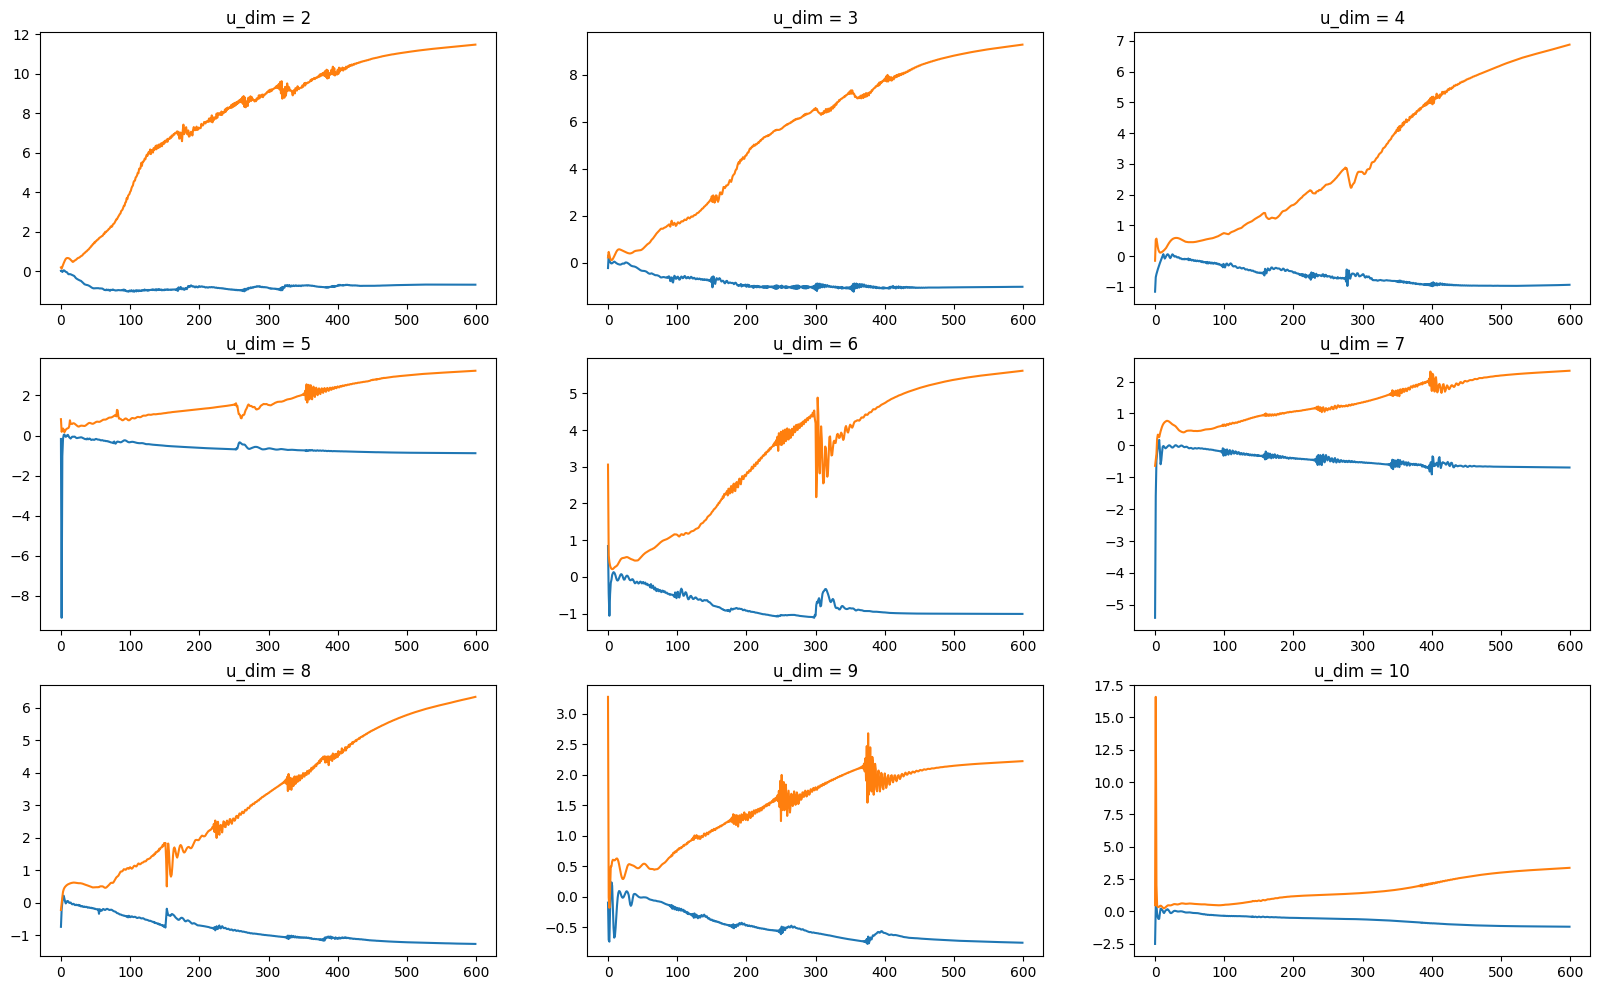

In [94]:
fig, axs = plt.subplots(3,3, figsize = (20,12))
for i in range(3):
    for j in range(3):
        axs[i,j].plot(min_currs_per_u[i*3+j])
        axs[i,j].plot(max_currs_per_u[i*3+j])
        axs[i,j].set_title(f"u_dim = {u_dims[i*3+j]}")

Min and max u values with changing u_dim:

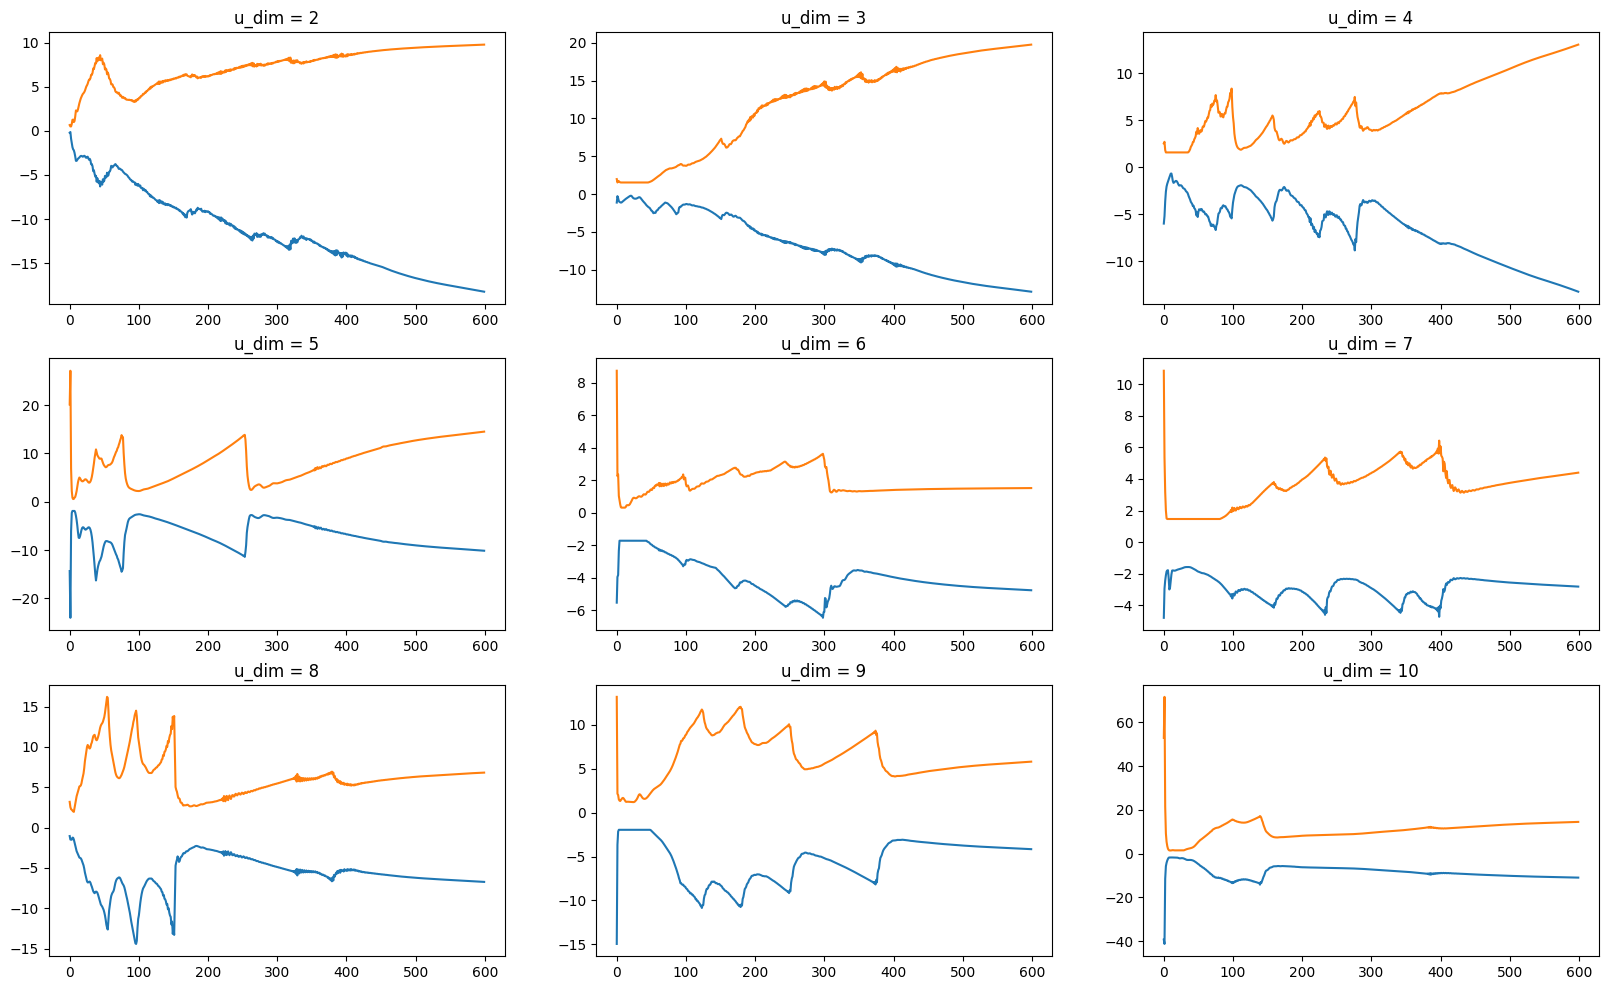

In [95]:
fig, axs = plt.subplots(3,3, figsize = (20,12))
for i in range(3):
    for j in range(3):
        axs[i,j].plot(min_us_per_u[i*3+j])
        axs[i,j].plot(max_us_per_u[i*3+j])
        axs[i,j].set_title(f"u_dim = {u_dims[i*3+j]}")

Training loss with changing u_dim:

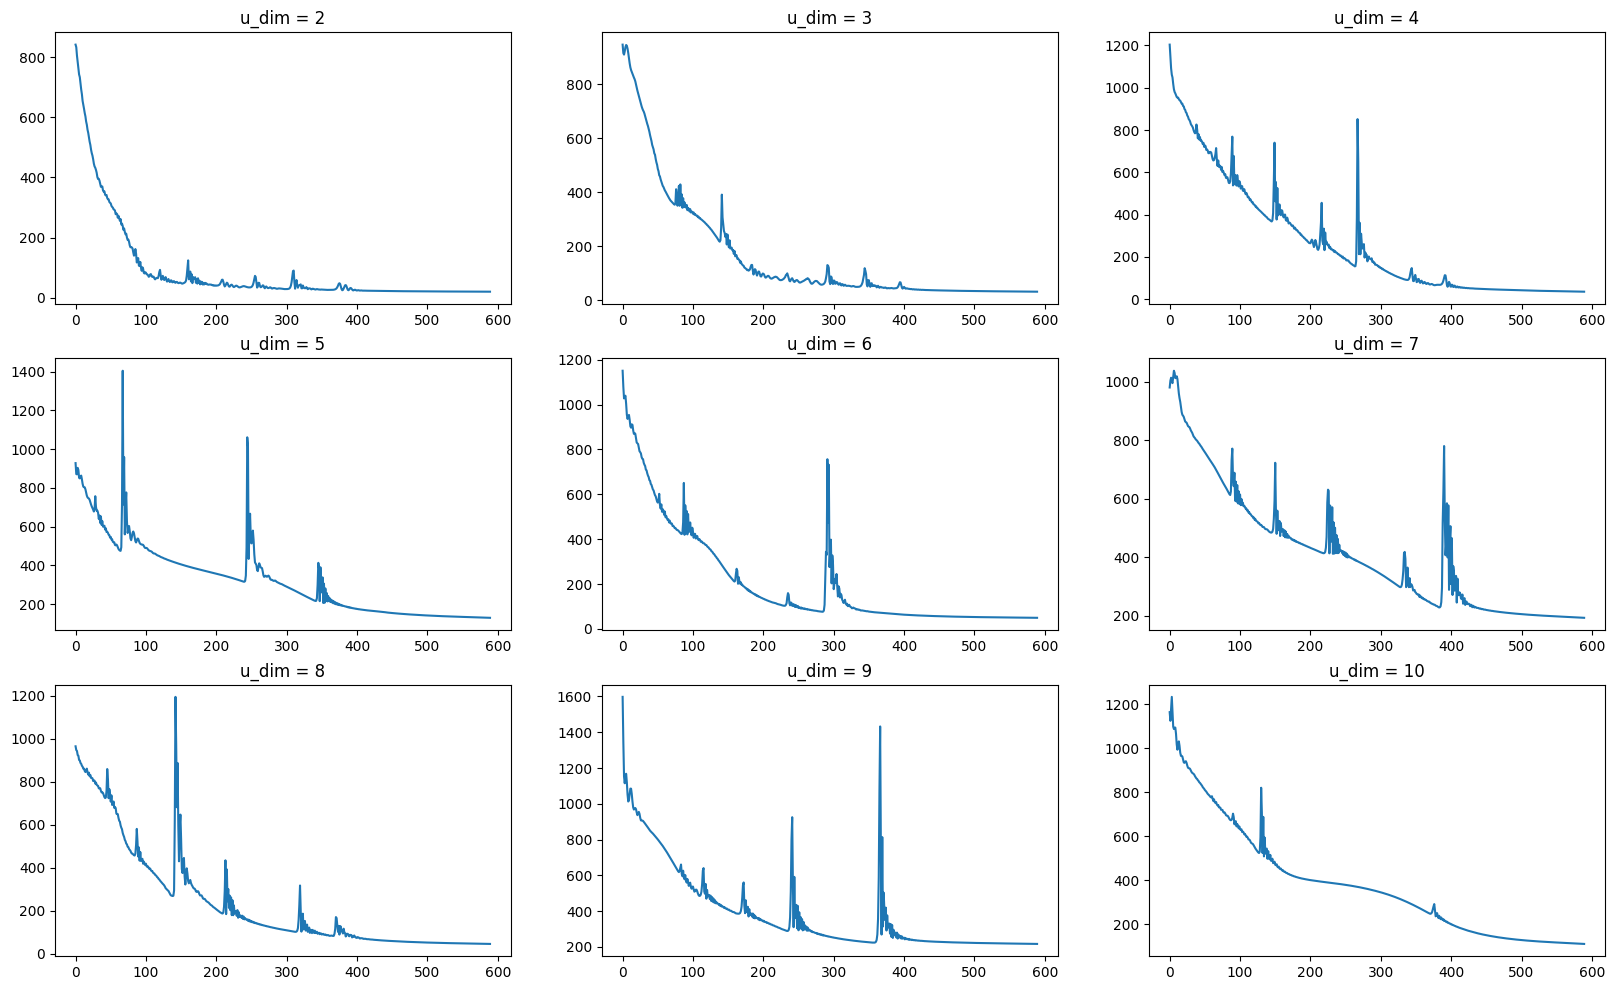

In [96]:
fig, axs = plt.subplots(3,3, figsize = (20,12))
for i in range(3):
    for j in range(3):
        axs[i,j].plot(losses_per_u[i*3+j][10:])
        axs[i,j].set_title(f"u_dim = {u_dims[i*3+j]}")

Added currents with changing width of the neural network:

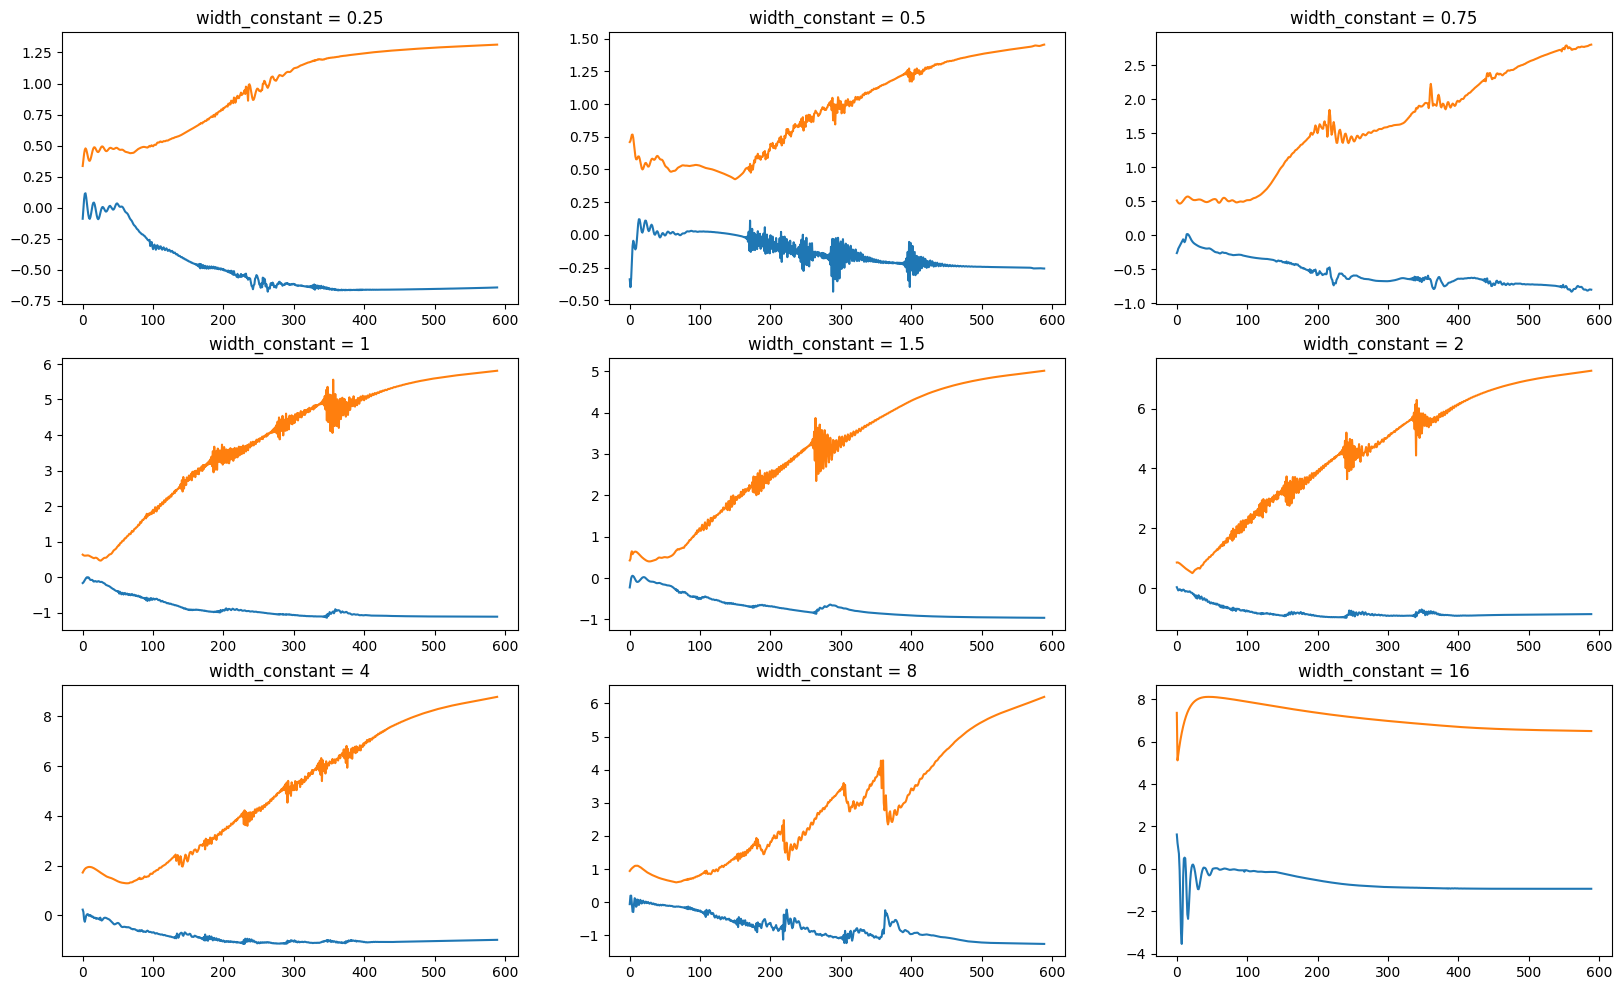

In [100]:
fig, axs = plt.subplots(3,3, figsize = (20,12))
for i in range(3):
    for j in range(3):
        axs[i,j].plot(min_currs_per_u[i*3+j][10:])
        axs[i,j].plot(max_currs_per_u[i*3+j][10:])
        axs[i,j].set_title(f"width_constant = {width_constants[i*3+j]}")

Min and max u values with changing width of the neural network:

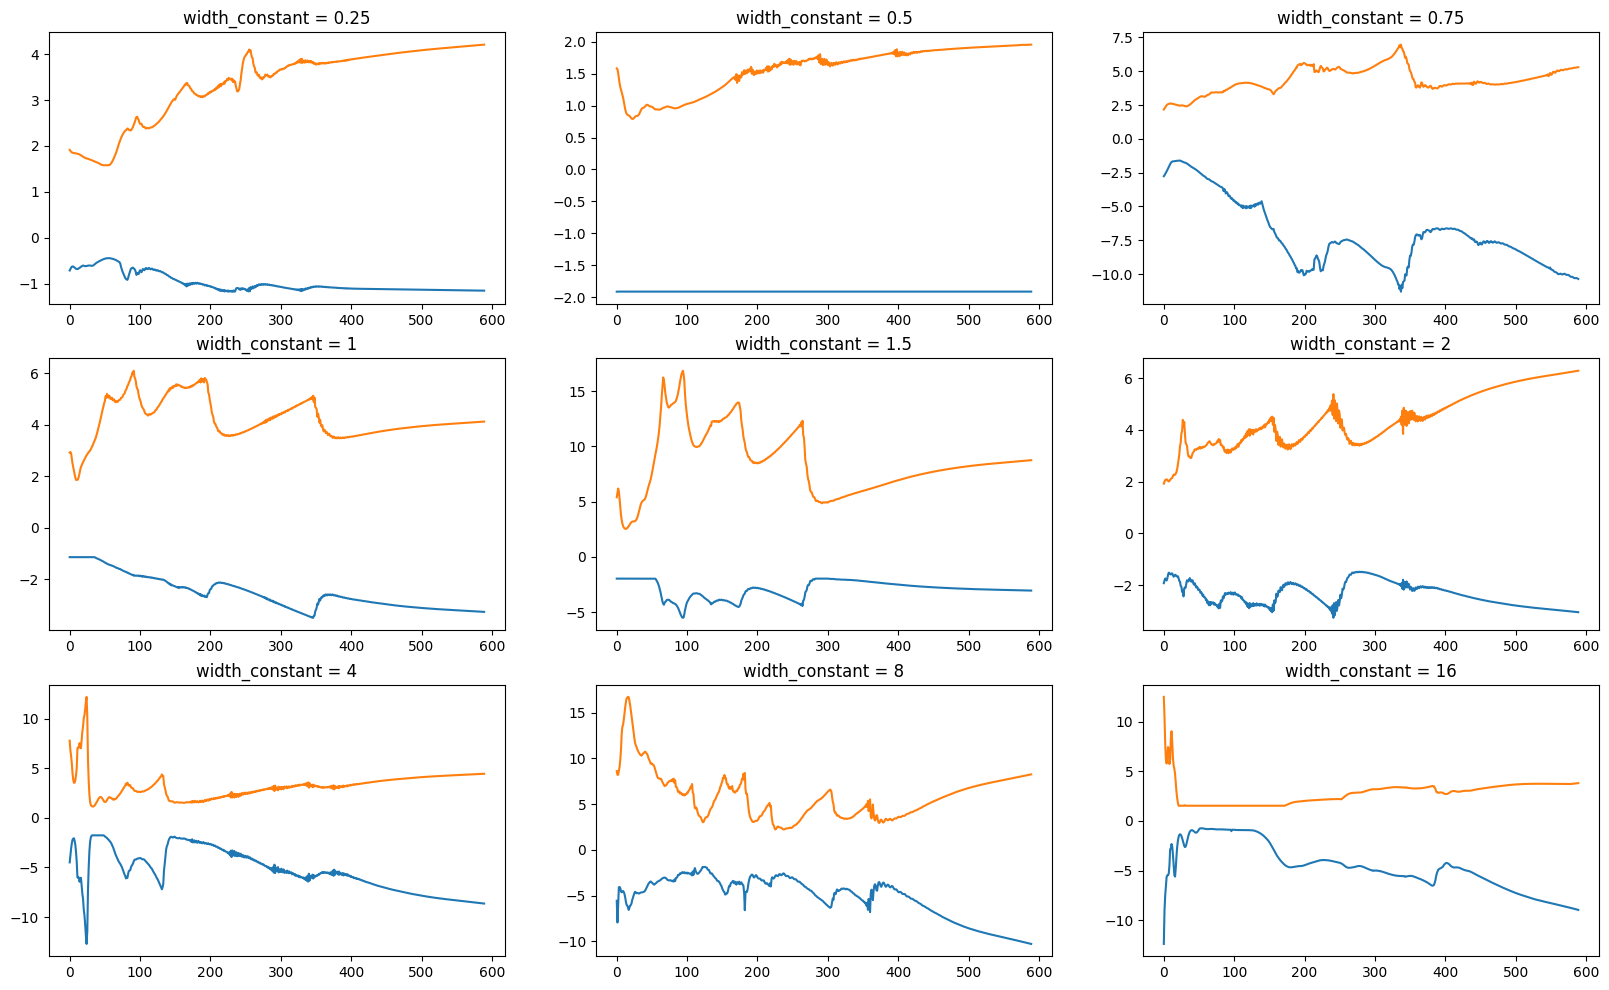

In [102]:
fig, axs = plt.subplots(3,3, figsize = (20,12))
for i in range(3):
    for j in range(3):
        axs[i,j].plot(min_us_per_u[i*3+j][10:])
        axs[i,j].plot(max_us_per_u[i*3+j][10:])
        axs[i,j].set_title(f"width_constant = {width_constants[i*3+j]}")


Training loss with changing width of the neural network:

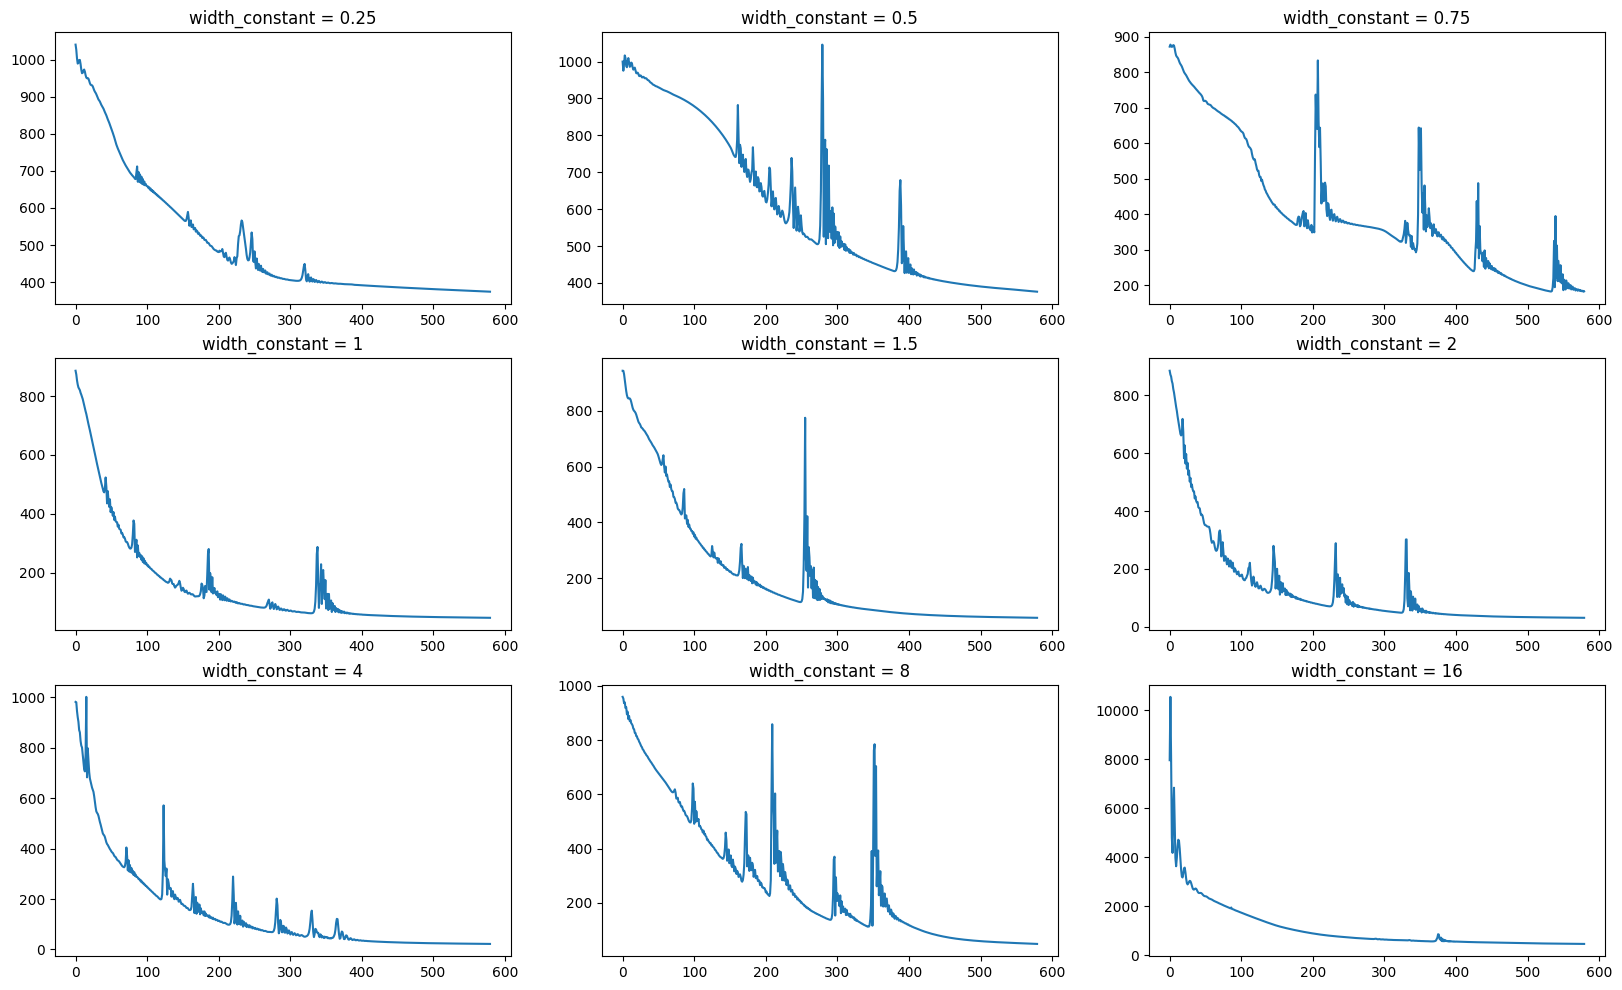

In [105]:
fig, axs = plt.subplots(3,3, figsize = (20,12))
for i in range(3):
    for j in range(3):
        axs[i,j].plot(losses_per_u[i*3+j][20:])
        axs[i,j].set_title(f"width_constant = {width_constants[i*3+j]}")

**Results with using sigmoid on NN output**

Added currents with changing u_dim:

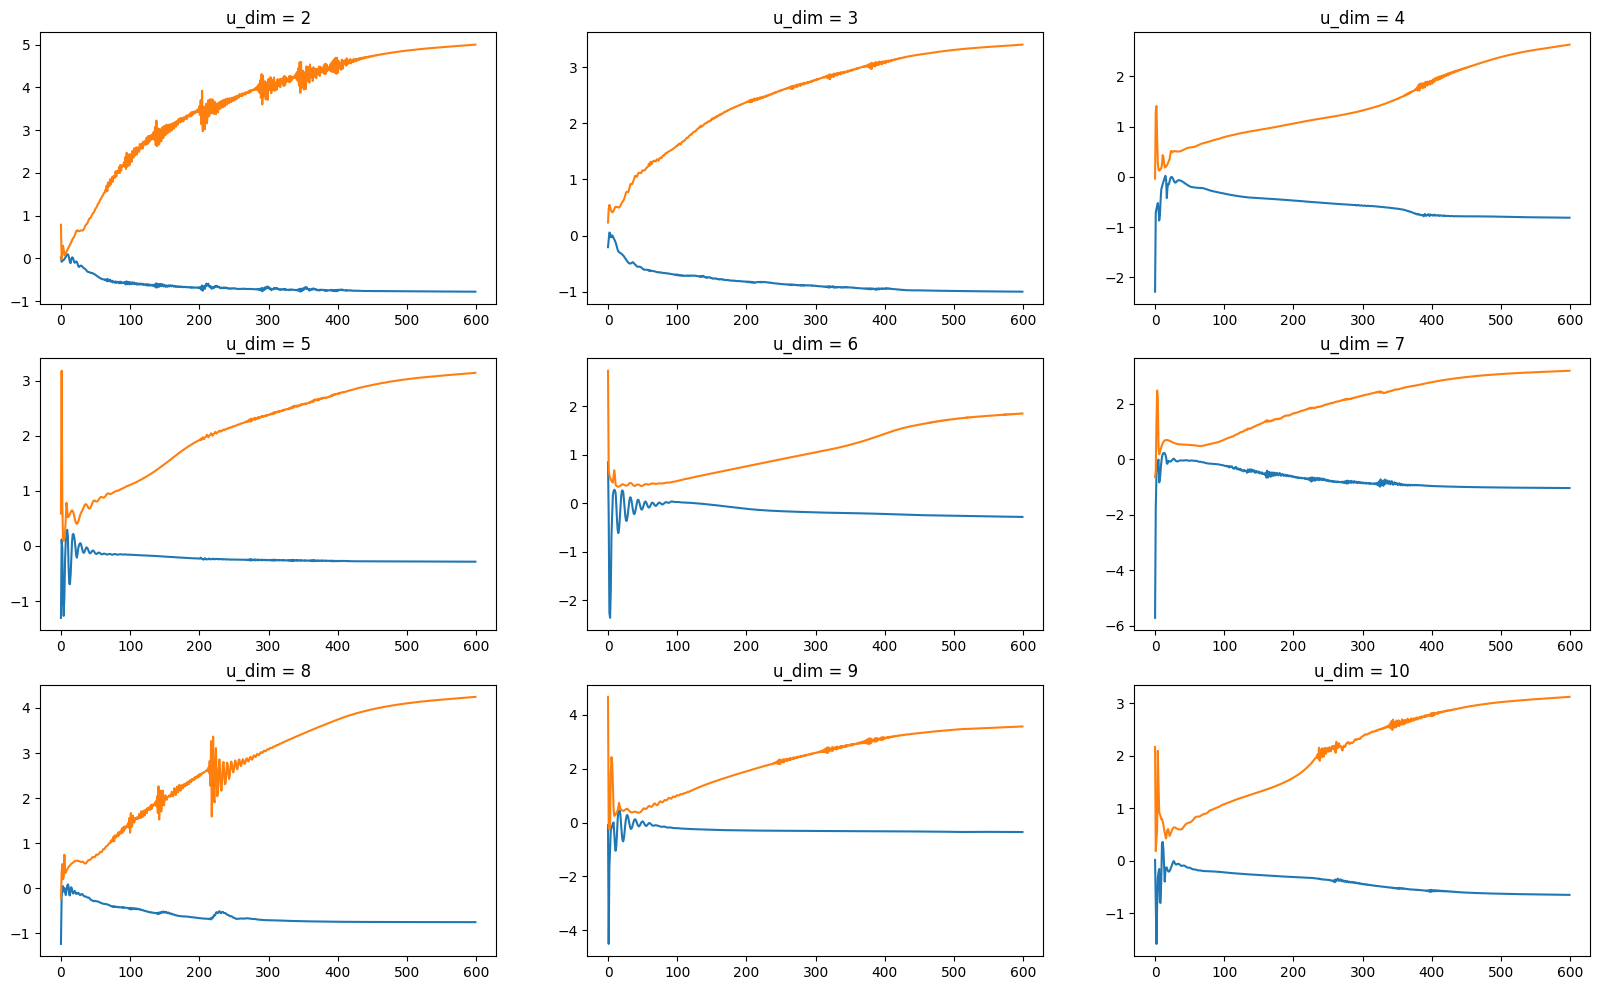

In [15]:
fig, axs = plt.subplots(3,3, figsize = (20,12))
for i in range(3):
    for j in range(3):
        axs[i,j].plot(min_currs_per_u[i*3+j])
        axs[i,j].plot(max_currs_per_u[i*3+j])
        axs[i,j].set_title(f"u_dim = {u_dims[i*3+j]}")

Min and max u values with changing u_dim:

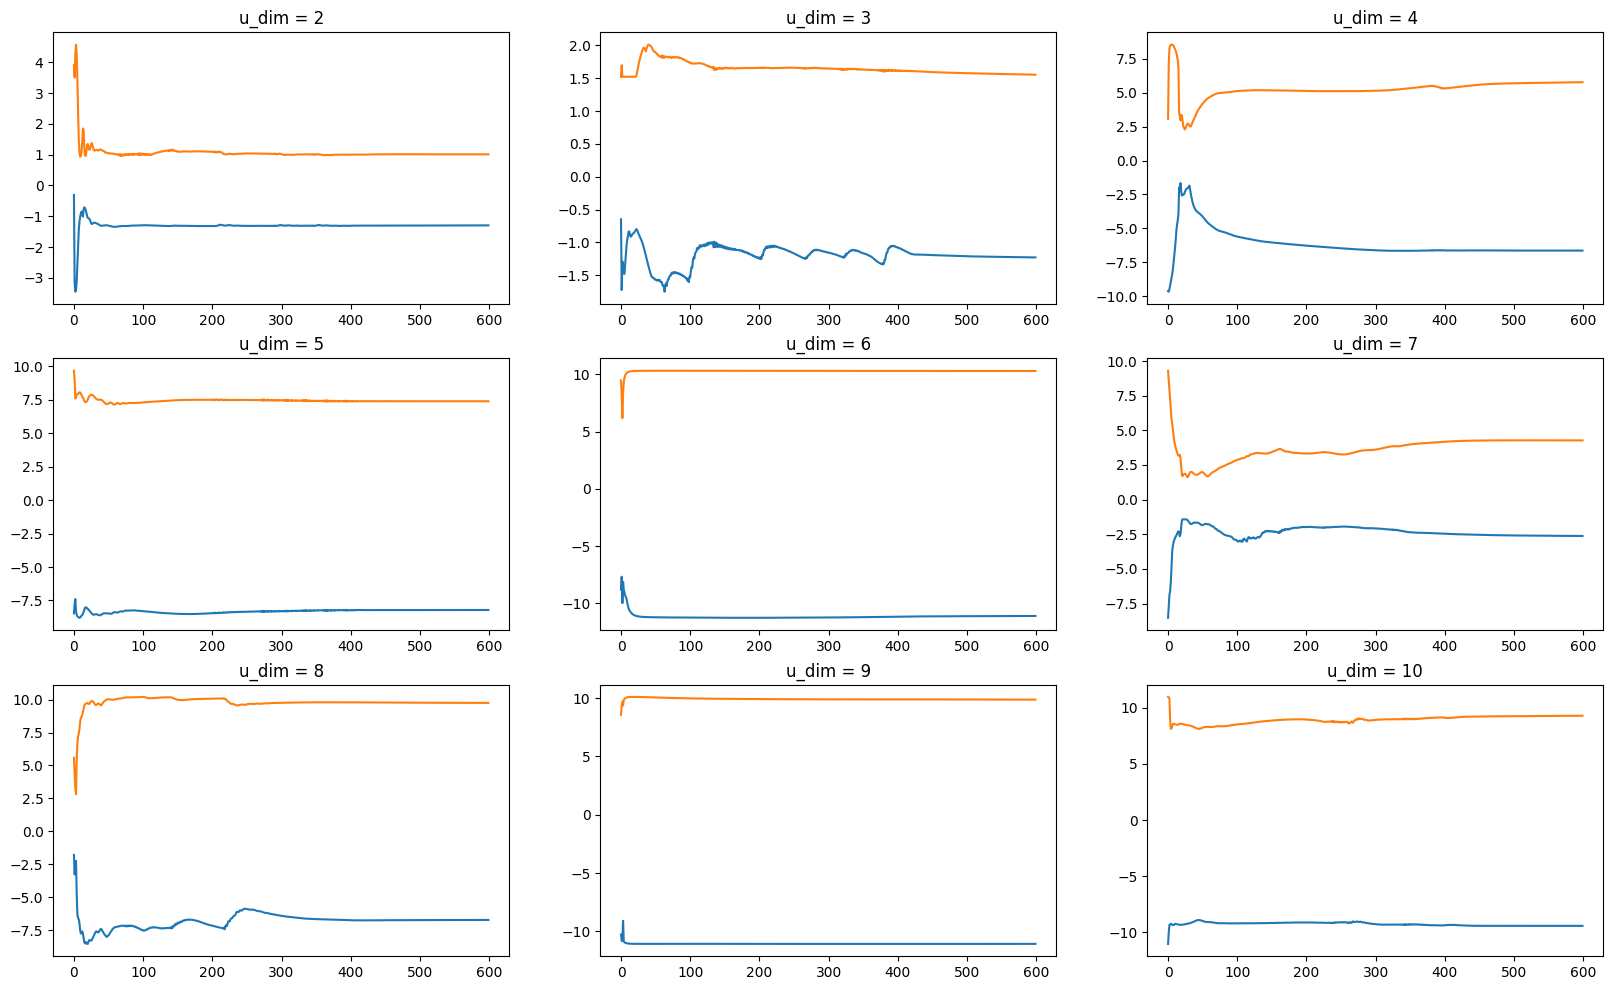

In [16]:
fig, axs = plt.subplots(3,3, figsize = (20,12))
for i in range(3):
    for j in range(3):
        axs[i,j].plot(min_us_per_u[i*3+j])
        axs[i,j].plot(max_us_per_u[i*3+j])
        axs[i,j].set_title(f"u_dim = {u_dims[i*3+j]}")

Training loss with changing u_dim:

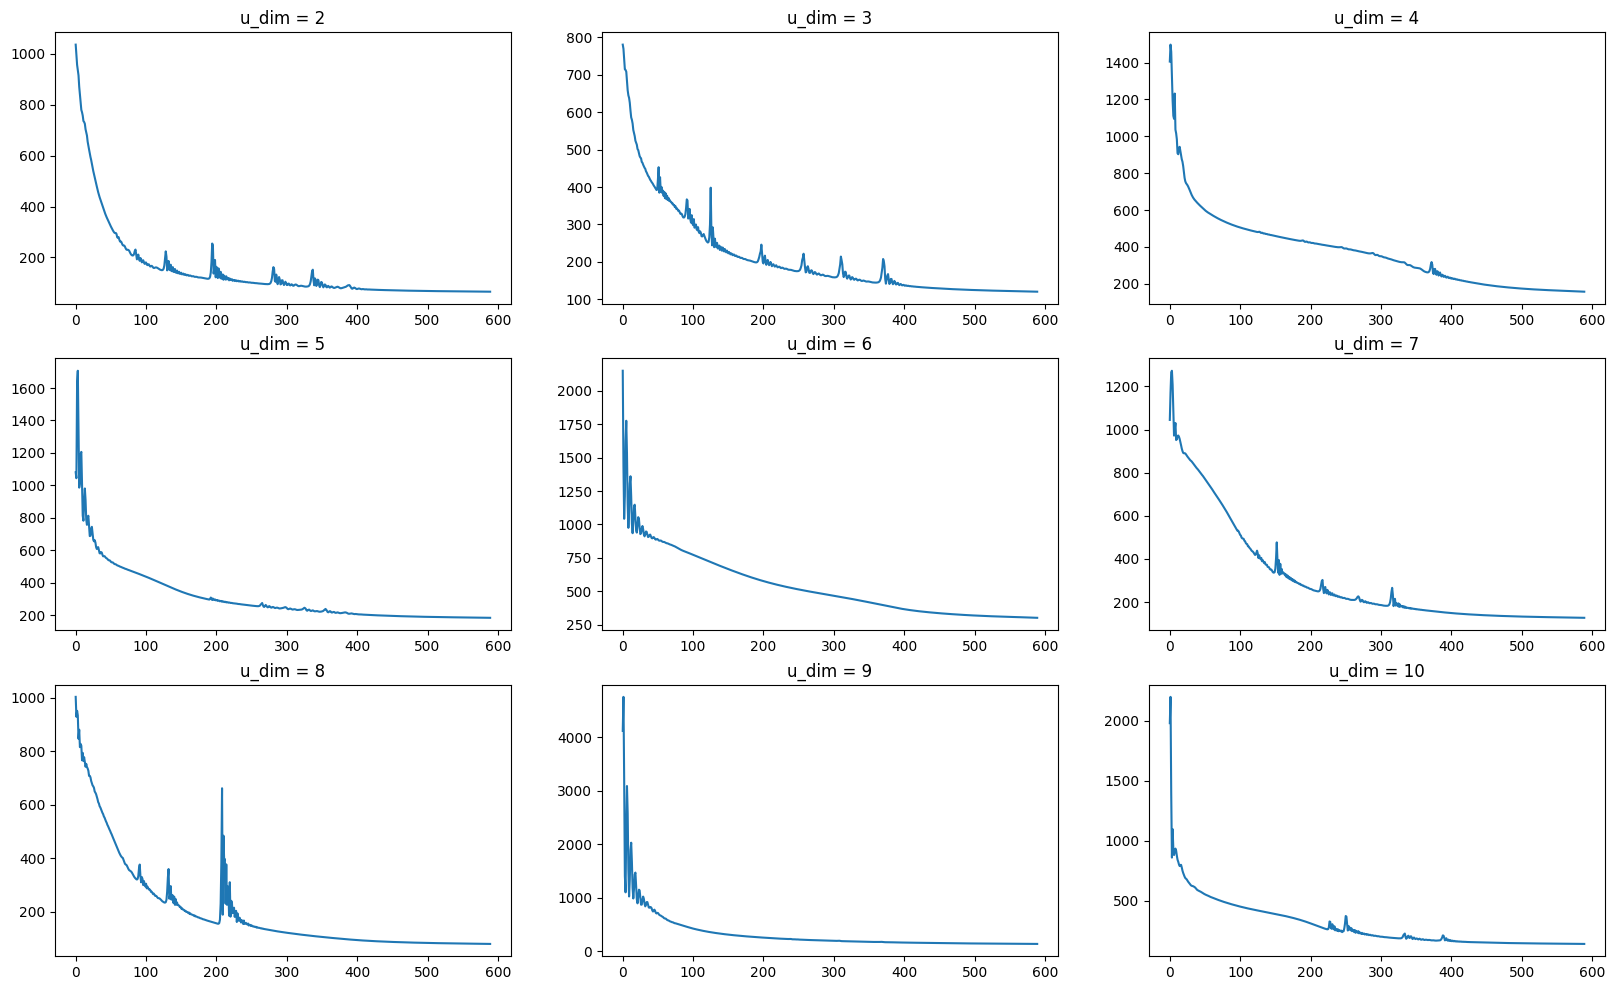

In [17]:
fig, axs = plt.subplots(3,3, figsize = (20,12))
for i in range(3):
    for j in range(3):
        axs[i,j].plot(losses_per_u[i*3+j][10:])
        axs[i,j].set_title(f"u_dim = {u_dims[i*3+j]}")